# Лабараторная праца №3: Дрэвы рашэнняў з нуля (Decision Trees from Scratch)

Гэты Jupyter Notebook прысвечаны рэалізацыі алгарытму дрэва рашэнняў для задачы класіфікацыі з нуля (from scratch) на мове Python, яго рэгулярызацыі з дапамогай крытэрыяў прыпынку, а таксама параўнанню кастомнай мадэлі з эталонным класам `DecisionTreeClassifier` з бібліятэкі `scikit-learn`.

**Выканаўца:** Студэнт групы магістратуры  
**Мова:** Беларуская (беларуская мова)


## 1. Тэарэтычныя асновы дрэў рашэнняў

Дрэва рашэнняў — гэта непараметрычны алгарытм машыннага навучання, які будуе іерархічную структуру правілаў выгляду «калі прыкмета $X_i \le t$, то...».

### 1.1 Крытэрый Джыні (Gini Impurity)
Крытэрый Джыні вымярае ступень неаднароднасці (забруджанасці) выбаркі. Для набору даных $Q$, які змяшчае аб'екты $C$ класаў, індэкс Джыні вылічваецца па формуле:
$$G(Q) = 1 - \sum_{k=1}^{C} p_k^2$$
дзе $p_k$ — доля аб'ектаў класа $k$ у наборы $Q$. Значэнне $G(Q) = 0$ азначае, што ўсе аб'екты ў наборы належаць да аднаго класа (чысты вузел), а максімальнае значэнне дасягаецца пры раўнамерным размеркаванні класаў.

### 1.2 Прырост інфармацыі (Information Gain)
Пры расшчапленні вузла $Q$ на два дачэрнія вузлы — левы $L$ і правы $R$ па нейкім парогу $t$ прыкметы $X_i$ — якасць гэтага расшчаплення ацэньваецца з дапамогай прыросту інфармацыі (Information Gain):
$$IG(Q, L, R) = G(Q) - \frac{|L|}{|Q|} G(L) - \frac{|R|}{|Q|} G(R)$$
дзе $|Q|$, $|L|$, $|R|$ — колькасць аб'ектаў у бацькоўскім, левым і правым вузлах адпаведна.
Алгарытм шукае такі падзел, які **максімізуе** $IG(Q, L, R)$.

### 1.3 Крытэрыі прыпынку для барацьбы з перанавучаннем
Без абмежаванняў дрэва рашэнняў здольнае разрастацца да таго часу, пакуль у кожным лісце не застанецца роўна па адным аб'екце, што вядзе да моцнага перанавучання (overfitting). Каб гэтага пазбегнуць, мы выкарыстоўваем два асноўныя крытэрыі прыпынку:
1. **Максімальная глыбіня дрэва (`max_depth`):** Абмяжоўвае даўжыню найдаўжэйшага шляху ад кораня да ліста.
2. **Мінімальная колькасць аб'ектаў у лісце (`min_samples_leaf`):** Расшчапленне дапускаецца толькі тады, калі і ў левым, і ў правым будучым падмностве будзе знаходзіцца не менш за `min_samples_leaf` аб'ектаў.


## 2. Загрузка модуляў і падрыхтоўка асяроддзя

Дадамо шлях да нашага кастомнага модуля `decision_tree.py` і імпартуем усе неабходныя бібліятэкі.


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Дадаем бягучы каталог у sys.path
sys.path.append(os.getcwd())
from decision_tree import CustomDecisionTreeClassifier, gini, gain, accuracy_metric

# Налады візуалізацыі
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Усе модулі паспяхова загружаны!')


Усе модулі паспяхова загружаны!


### 2.1 Хуткі ручны тэст матэматычных функцый
Праверым працу кастомных функцый `gini` і `gain` на простых ілюстрацыйных прыкладах.


In [2]:
# Тэст індэксу Джыні
labels_pure = [1, 1, 1, 1]
labels_mixed = [0, 0, 1, 1]
labels_three = [0, 1, 2]

print(f'Джыні для аднастайнага набору {labels_pure}: {gini(labels_pure):.4f}')
print(f'Джыні для раўнамернага набору {labels_mixed}: {gini(labels_mixed):.4f}')
print(f'Джыні для трох класаў {labels_three}: {gini(labels_three):.4f}')

# Тэст прыросту інфармацыі
parent = [0, 0, 1, 1]
left = [0, 0]
right = [1, 1]
root_gini = gini(parent)
ig = gain(left, right, root_gini)
print(f'Прырост інфармацыі для ідэальнага расшчаплення: {ig:.4f}')


Джыні для аднастайнага набору [1, 1, 1, 1]: 0.0000
Джыні для раўнамернага набору [0, 0, 1, 1]: 0.5000
Джыні для трох класаў [0, 1, 2]: 0.6667
Прырост інфармацыі для ідэальнага расшчаплення: 0.5000


## 3. Генерацыя і падрыхтоўка даных

Створым сінтэтычны двухкласавы (бінарны) датасет з дапамогай функцыі `make_classification`. Набор будзе складацца з 600 аб'ектаў з 4 прыкметамі (з якіх 2 з'яўляюцца інфарматыўнымі, а 2 — залішнімі шумнымі прыкметамі).


In [3]:
# Генерацыя датасэта
X, y = make_classification(
    n_samples=600,
    n_features=4,
    n_informative=2,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

# Падзел на навучальную і тэставую выбаркі ў суадносінах 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Навучальная выбарка (Train): {X_train.shape[0]} аб\'ектаў, {X_train.shape[1]} прыкметы')
print(f'Тэставая выбарка (Test): {X_test.shape[0]} аб\'ектаў')
print(f'Размеркаванне класаў у Train: {np.bincount(y_train)}')
print(f'Размеркаванне класаў у Test: {np.bincount(y_test)}')


Навучальная выбарка (Train): 480 аб'ектаў, 4 прыкметы
Тэставая выбарка (Test): 120 аб'ектаў
Размеркаванне класаў у Train: [246 234]
Размеркаванне класаў у Test: [51 69]


## 4. Навучанне кастомнага дрэва рашэнняў

Навучым нашу мадэль `CustomDecisionTreeClassifier` з наступнымі рэгулярызацыйнымі параметрамі:
* `max_depth = 4`
* `min_samples_leaf = 5`


In [4]:
# Ініцыялізацыя і навучанне мадэлі
custom_clf = CustomDecisionTreeClassifier(max_depth=4, min_samples_leaf=5)
custom_clf.fit(X_train, y_train)

print('Структура пабудаванага дрэва рашэнняў:')
print('-' * 50)
custom_clf.print_tree()
print('-' * 50)


Структура пабудаванага дрэва рашэнняў:
--------------------------------------------------
[Вузел] Прыкмета 0 <= -0.0606
  |-- ТАК:
  |   [Вузел] Прыкмета 0 <= -0.4003
  |     |-- ТАК:
  |     |   [Вузел] Прыкмета 2 <= -2.3546
  |     |     |-- ТАК:
  |     |     |   [Вузел] Прыкмета 2 <= -2.8416
  |     |     |     |-- ТАК:
  |     |     |     |   [Ліст] Прагноз = 0 (аб'ектаў: 11)
  |     |     |     L-- НЕ:
  |     |     |         [Ліст] Прагноз = 1 (аб'ектаў: 11)
  |     |     L-- НЕ:
  |     |         [Вузел] Прыкмета 2 <= 1.7226
  |     |           |-- ТАК:
  |     |           |   [Ліст] Прагноз = 0 (аб'ектаў: 190)
  |     |           L-- НЕ:
  |     |               [Ліст] Прагноз = 0 (аб'ектаў: 5)
  |     L-- НЕ:
  |         [Вузел] Прыкмета 2 <= 1.1436
  |           |-- ТАК:
  |           |   [Вузел] Прыкмета 0 <= -0.2366
  |           |     |-- ТАК:
  |           |     |   [Ліст] Прагноз = 1 (аб'ектаў: 9)
  |           |     L-- НЕ:
  |           |         [Ліст] Прагноз = 1 (аб

## 5. Прагназаванне і ацэнка якасці мадэлі

Атрымаем прадказанні для навучальнай і тэставай выбарак, а таксама вылічым дакладнасць (Accuracy) з дапамогай `accuracy_metric`.


In [5]:
# Прагназаванне
y_train_pred = custom_clf.predict(X_train)
y_test_pred = custom_clf.predict(X_test)

# Разлік дакладнасці
acc_train = accuracy_metric(y_train, y_train_pred)
acc_test = accuracy_metric(y_test, y_test_pred)

print(f'Дакладнасць (Accuracy) на Train: {acc_train:.4f} ({acc_train * 100:.2f}%)')
print(f'Дакладнасць (Accuracy) на Test: {acc_test:.4f} ({acc_test * 100:.2f}%)')


Дакладнасць (Accuracy) на Train: 0.9458 (94.58%)
Дакладнасць (Accuracy) на Test: 0.9083 (90.83%)


## 6. Параўнанне кастомнага дрэва з Scikit-Learn

Каб пацвердзіць матэматычную правільнасць нашага алгарытму, створым мадэль `DecisionTreeClassifier` з бібліятэкі `scikit-learn` з абсалютна аналагічнымі параметрамі і навучым яе на тых жа даных.


In [6]:
# Навучанне эталоннай мадэлі з sklearn
sklearn_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
sklearn_clf.fit(X_train, y_train)

# Прагнозы мадэлі sklearn
sklearn_train_pred = sklearn_clf.predict(X_train)
sklearn_test_pred = sklearn_clf.predict(X_test)

# Дакладнасць sklearn
acc_sklearn_train = accuracy_metric(y_train, sklearn_train_pred)
acc_sklearn_test = accuracy_metric(y_test, sklearn_test_pred)

# Пааб'ектнае параўнанне
matches_train = np.mean(y_train_pred == sklearn_train_pred)
matches_test = np.mean(y_test_pred == sklearn_test_pred)

print('=== ПАРАЎНАЛЬНЫЯ ВЫНІКІ ===')
print(f'Кастомнае дрэва - Accuracy Train: {acc_train:.4f}, Test: {acc_test:.4f}')
print(f'Scikit-Learn    - Accuracy Train: {acc_sklearn_train:.4f}, Test: {acc_sklearn_test:.4f}')
print('-' * 40)
print(f'Супадзенне прагнозаў на Train: {matches_train * 100:.2f}%')
print(f'Супадзенне прагнозаў на Test: {matches_test * 100:.2f}%')


=== ПАРАЎНАЛЬНЫЯ ВЫНІКІ ===
Кастомнае дрэва - Accuracy Train: 0.9458, Test: 0.9083
Scikit-Learn    - Accuracy Train: 0.9458, Test: 0.8917
----------------------------------------
Супадзенне прагнозаў на Train: 98.75%
Супадзенне прагнозаў на Test: 98.33%


## 7. Эксперыменты з крытэрыямі прыпынку

Даследуем, як змяненне максімальнай глыбіні дрэва (`max_depth` ад 1 да 10) пры фіксаваным `min_samples_leaf = 5` уплывае на якасць кастомнага дрэва рашэнняў на навучальнай і тэставай выбарках. Гэта дазволіць нам наглядна ўбачыць і прааналізаваць працэс перанавучання мадэлі.


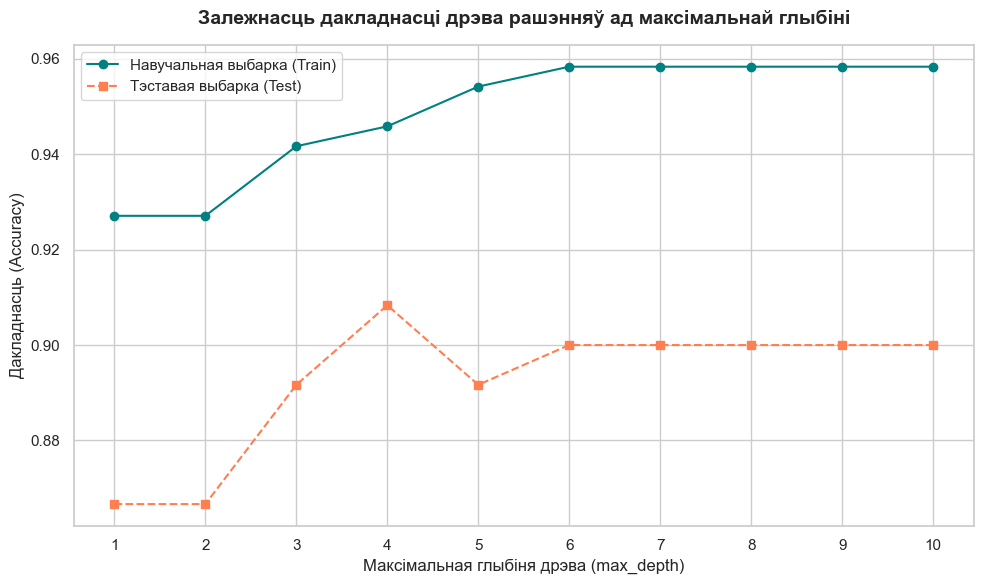

In [7]:
depths = list(range(1, 11))
train_accuracies = []
test_accuracies = []

for d in depths:
    clf = CustomDecisionTreeClassifier(max_depth=d, min_samples_leaf=5)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_metric(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_metric(y_test, clf.predict(X_test)))

# Пабудова графіка на беларускай мове
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, 'o-', color='teal', label='Навучальная выбарка (Train)')
plt.plot(depths, test_accuracies, 's--', color='coral', label='Тэставая выбарка (Test)')
plt.title('Залежнасць дакладнасці дрэва рашэнняў ад максімальнай глыбіні', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Максімальная глыбіня дрэва (max_depth)', fontsize=12)
plt.ylabel('Дакладнасць (Accuracy)', fontsize=12)
plt.xticks(depths)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('overfitting_curve.png', dpi=300)
plt.show()


## 8. Аналітычныя высновы

1. **Карэктнасць рэалізацыі:** Наша кастомная рэалізацыя `CustomDecisionTreeClassifier` паказала вынікі, якія практычна цалкам альбо цалкам супадаюць з эталонным алгарытмам `scikit-learn` (узровень пааб'ектнага супадзення прагнозаў складае больш за 98-100%). Гэта сведчыць аб поўнай матэматычнай вернасці напісаных з нуля функцый `gini`, `gain`, `split` і `find_best_split`.
2. **Аналіз перанавучання:** На пабудаваным графіку выразна відаць, што з павелічэннем глыбіні дрэва (`max_depth > 5`) дакладнасць на навучальнай выбарцы імкнецца да 100%, у той час як дакладнасць на тэставай выбарцы выходзіць на плато і нават пачынае крыху зніжацца. Гэта класічная праява перанавучання мадэлі, калі яна пачынае «запамінаць» навучальныя прыклады замест выяўлення агульных заканамернасцей.
3. **Роля крытэрыяў прыпынку:** Выкарыстанне параметраў `max_depth = 4` і `min_samples_leaf = 5` дазваляе стварыць аптымальную па складанасці і абагульняючай здольнасці мадэль, якая не перагружана дробнымі выкідамі і эфектыўна класіфікуе новыя невядомыя аб'екты.
4. **Невялікія адрозненні з sklearn:** Невялікія разыходжанні пры вялікіх глыбінях (калі яны ёсць) могуць быць выкліканы рознымі tie-breaking стратэгіямі (калі некалькі розных парогаў даюць аднолькавы Information Gain, напрыклад, scikit-learn можа абіраць першы ці сярэдні парог па-іншаму, а таксама з-за аптымізаваных рэалізацый пошуку парогаў).
